# Self-Supervised Image Representation Learning
## using Masked Autoencoders (MAE)
**Kaggle T4x2 | TinyImageNet | Pure PyTorch**

## 1. Environment Setup

In [1]:
!pip install einops scikit-image gradio --quiet
print('Packages installed.')

Packages installed.


In [2]:
import os, math, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity  as calc_ssim

def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True

set_seed(42)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark        = True

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f'Device : {device}  |  GPUs : {num_gpus}')
for i in range(num_gpus):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')
print(f'PyTorch: {torch.__version__}')

Device : cuda  |  GPUs : 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
PyTorch: 2.9.0+cu126


## 2. Dataset

In [3]:
import glob
hits = glob.glob('/kaggle/input/**/tiny-imagenet-200', recursive=True)
if hits:
    DATASET_PATH = hits[0]
    print(f'Dataset found: {DATASET_PATH}')
else:
    print('Available in /kaggle/input/:')
    for d in os.listdir('/kaggle/input'):
        print(f'  {d}/')
        for s in os.listdir(f'/kaggle/input/{d}'): print(f'    {s}')
    raise FileNotFoundError('Add akash2sharma/tiny-imagenet to this notebook.')
TRAIN_DIR = os.path.join(DATASET_PATH, 'train')
VAL_DIR   = os.path.join(DATASET_PATH, 'val')
classes = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR,d))]
print(f'Classes : {len(classes)}')

Dataset found: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200
Classes : 200


In [4]:
class Config:
    IMAGE_SIZE    = 224
    PATCH_SIZE    = 16
    NUM_PATCHES   = (224 // 16) ** 2
    MASK_RATIO    = 0.75
    NUM_VISIBLE   = int(NUM_PATCHES * (1 - MASK_RATIO))
    NUM_MASKED    = NUM_PATCHES - NUM_VISIBLE
    IN_CHANNELS   = 3
    ENC_DIM       = 768
    ENC_DEPTH     = 12
    ENC_HEADS     = 12
    ENC_MLP_RATIO = 4.0
    DEC_DIM       = 384
    DEC_DEPTH     = 8
    DEC_HEADS     = 6
    DEC_MLP_RATIO = 4.0
    BATCH_SIZE    = 32
    EPOCHS        = 40
    LR            = 1.5e-4
    WEIGHT_DECAY  = 0.05
    WARMUP_EPOCHS = 5
    CLIP_GRAD     = 1.0
    USE_AMP       = True
    LOG_INTERVAL  = 200
    NUM_WORKERS   = 2
    PIN_MEMORY    = True
    LATEST_CKPT   = '/kaggle/working/mae_latest.pth'
    BEST_CKPT     = '/kaggle/working/mae_best.pth'

cfg = Config()
print(f'Patches:{cfg.NUM_PATCHES}  Visible:{cfg.NUM_VISIBLE}  Masked:{cfg.NUM_MASKED}')
print(f'Epochs:{cfg.EPOCHS}  Batch:{cfg.BATCH_SIZE}  LR:{cfg.LR}')

Patches:196  Visible:49  Masked:147
Epochs:40  Batch:32  LR:0.00015


In [5]:
class TinyImageNetDataset(Dataset):
    def __init__(self, root, split='train', transform=None):
        self.transform = transform
        self.samples   = []
        if split == 'train':
            for cls in sorted(os.listdir(os.path.join(root,'train'))):
                d = os.path.join(root,'train',cls,'images')
                if os.path.isdir(d):
                    for f in os.listdir(d):
                        if f.lower().endswith(('.jpeg','.jpg','.png')):
                            self.samples.append(os.path.join(d,f))
        else:
            d1 = os.path.join(root,'val','images')
            if os.path.isdir(d1):
                for f in os.listdir(d1):
                    if f.lower().endswith(('.jpeg','.jpg','.png')):
                        self.samples.append(os.path.join(d1,f))
            else:
                for cls in os.listdir(os.path.join(root,'val')):
                    p = os.path.join(root,'val',cls)
                    if not os.path.isdir(p): continue
                    sub = os.path.join(p,'images')
                    folder = sub if os.path.isdir(sub) else p
                    for f in os.listdir(folder):
                        full = os.path.join(folder,f)
                        if os.path.isfile(full) and f.lower().endswith(('.jpeg','.jpg','.png')):
                            self.samples.append(full)
        print(f'  {split:5s}: {len(self.samples):6d} images')
    def __len__(self):  return len(self.samples)
    def __getitem__(self, i):
        try:   img = Image.open(self.samples[i]).convert('RGB')
        except: img = Image.new('RGB',(64,64),128)
        return self.transform(img) if self.transform else img

train_tf = T.Compose([T.Resize(256),T.RandomCrop(cfg.IMAGE_SIZE),
    T.RandomHorizontalFlip(),T.ColorJitter(.4,.4,.4,.1),
    T.ToTensor(),T.Normalize([.485,.456,.406],[.229,.224,.225])])
val_tf = T.Compose([T.Resize(256),T.CenterCrop(cfg.IMAGE_SIZE),
    T.ToTensor(),T.Normalize([.485,.456,.406],[.229,.224,.225])])

print('Loading datasets...')
train_ds = TinyImageNetDataset(DATASET_PATH,'train',train_tf)
val_ds   = TinyImageNetDataset(DATASET_PATH,'val',  val_tf)
train_dl = DataLoader(train_ds,batch_size=cfg.BATCH_SIZE,shuffle=True,
    num_workers=cfg.NUM_WORKERS,pin_memory=cfg.PIN_MEMORY,drop_last=True,persistent_workers=True)
val_dl   = DataLoader(val_ds,  batch_size=cfg.BATCH_SIZE,shuffle=False,
    num_workers=cfg.NUM_WORKERS,pin_memory=cfg.PIN_MEMORY,persistent_workers=True)
print(f'Train batches:{len(train_dl)}  Val batches:{len(val_dl)}')

Loading datasets...
  train: 100000 images
  val  :  10000 images
Train batches:3125  Val batches:313


## 3. Model Architecture

In [6]:
# Part 1: Patchification & Masking
def patchify(imgs, p=16):
    B,C,H,W = imgs.shape; h = H//p
    x = imgs.reshape(B,C,h,p,h,p)
    x = torch.einsum('bchpwq->bhwpqc',x)
    return x.reshape(B,h*h,p*p*C)

def unpatchify(x, p=16, s=224):
    B,N,D = x.shape; C=D//(p*p); h=s//p
    x = x.reshape(B,h,h,p,p,C)
    x = torch.einsum('bhwpqc->bchpwq',x)
    return x.reshape(B,C,h*p,h*p)

def random_masking(x, ratio=0.75):
    B,N,D  = x.shape
    keep   = int(N*(1-ratio))
    noise  = torch.rand(B,N,device=x.device)
    ids_s  = torch.argsort(noise,dim=1)
    ids_r  = torch.argsort(ids_s, dim=1)
    x_vis  = torch.gather(x,1,ids_s[:,:keep].unsqueeze(-1).expand(-1,-1,D))
    mask   = torch.ones(B,N,device=x.device)
    mask[:,:keep] = 0
    mask   = torch.gather(mask,1,ids_r)
    return x_vis, mask, ids_r

_t = torch.randn(2,3,224,224)
assert torch.allclose(_t,unpatchify(patchify(_t))), 'patchify round-trip FAILED'
print('Patchify / Unpatchify  OK')
print(f'  patchify output : {patchify(_t).shape}')
print(f'  visible:49 (25%)  masked:147 (75%)')
del _t

Patchify / Unpatchify  OK
  patchify output : torch.Size([2, 196, 768])
  visible:49 (25%)  masked:147 (75%)


In [7]:
# Pure-PyTorch Transformer Building Blocks
class Attention(nn.Module):
    def __init__(self,dim,heads,drop=0.):
        super().__init__()
        self.heads=heads; self.hd=dim//heads; self.scale=self.hd**-0.5
        self.qkv=nn.Linear(dim,dim*3); self.proj=nn.Linear(dim,dim)
        self.drop=nn.Dropout(drop)
    def forward(self,x):
        B,N,C=x.shape
        qkv=self.qkv(x).reshape(B,N,3,self.heads,self.hd).permute(2,0,3,1,4)
        q,k,v=qkv.unbind(0)
        a=self.drop((q@k.transpose(-2,-1))*self.scale).softmax(-1)
        return self.proj((a@v).transpose(1,2).reshape(B,N,C))

class FFN(nn.Module):
    def __init__(self,dim,ratio=4.,drop=0.):
        super().__init__()
        h=int(dim*ratio)
        self.net=nn.Sequential(nn.Linear(dim,h),nn.GELU(),nn.Dropout(drop),
                               nn.Linear(h,dim),nn.Dropout(drop))
    def forward(self,x): return self.net(x)

class Block(nn.Module):
    def __init__(self,dim,heads,ratio=4.,drop=0.):
        super().__init__()
        self.n1=nn.LayerNorm(dim); self.attn=Attention(dim,heads,drop)
        self.n2=nn.LayerNorm(dim); self.ffn =FFN(dim,ratio,drop)
    def forward(self,x):
        x=x+self.attn(self.n1(x))
        x=x+self.ffn(self.n2(x))
        return x

def sincos2d(dim,gs):
    gh=np.arange(gs,dtype=np.float32); gw=np.arange(gs,dtype=np.float32)
    grid=np.stack(np.meshgrid(gw,gh),0).reshape(2,1,gs,gs)
    def half(d,pos):
        om=1./10000**(np.arange(d//2,dtype=np.float64)/(d/2.))
        p=pos.reshape(-1); o=np.einsum('m,d->md',p,om)
        return np.concatenate([np.sin(o),np.cos(o)],1).astype(np.float32)
    return np.concatenate([half(dim//2,grid[0]),half(dim//2,grid[1])],1)

def _iw(m):
    if isinstance(m,nn.Linear):
        nn.init.trunc_normal_(m.weight,std=0.02)
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m,nn.LayerNorm):
        nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

print('Transformer blocks  OK')

Transformer blocks  OK


In [8]:
# MAE Encoder  ViT-Base B/16  ~86 M params
class MAEEncoder(nn.Module):
    def __init__(self,img=224,p=16,c=3,dim=768,depth=12,heads=12,ratio=4.):
        super().__init__()
        self.p=p; N=(img//p)**2
        self.embed=nn.Linear(p*p*c,dim)
        self.cls=nn.Parameter(torch.zeros(1,1,dim))
        self.register_buffer('pe',torch.zeros(1,N+1,dim))
        pe=sincos2d(dim,img//p)
        pe=np.concatenate([np.zeros((1,dim)),pe],0)
        self.pe.data.copy_(torch.from_numpy(pe).float().unsqueeze(0))
        self.blocks=nn.ModuleList([Block(dim,heads,ratio) for _ in range(depth)])
        self.norm=nn.LayerNorm(dim)
        nn.init.trunc_normal_(self.cls,std=0.02)
        self.apply(_iw)
    def forward(self,imgs,mask_ratio=0.75):
        x=self.embed(patchify(imgs,self.p))
        x=x+self.pe[:,1:,:]
        x,mask,ids=random_masking(x,mask_ratio)
        cls=self.cls.expand(x.shape[0],-1,-1)+self.pe[:,:1,:]
        x=torch.cat([cls,x],1)
        for b in self.blocks: x=b(x)
        return self.norm(x),mask,ids

ep=sum(p.numel() for p in MAEEncoder().parameters())/1e6
print(f'MAE Encoder  OK  ({ep:.1f} M params)')

MAE Encoder  OK  (85.6 M params)


In [9]:
# MAE Decoder  ViT-Small S/16  ~22 M params
class MAEDecoder(nn.Module):
    def __init__(self,img=224,p=16,c=3,enc_dim=768,dim=384,depth=8,heads=6,ratio=4.):
        super().__init__()
        N=(img//p)**2; self.pd=p*p*c
        self.proj=nn.Linear(enc_dim,dim)
        self.mask_tok=nn.Parameter(torch.zeros(1,1,dim))
        self.register_buffer('pe',torch.zeros(1,N+1,dim))
        pe=sincos2d(dim,img//p)
        pe=np.concatenate([np.zeros((1,dim)),pe],0)
        self.pe.data.copy_(torch.from_numpy(pe).float().unsqueeze(0))
        self.blocks=nn.ModuleList([Block(dim,heads,ratio) for _ in range(depth)])
        self.norm=nn.LayerNorm(dim)
        self.pred=nn.Linear(dim,self.pd)
        nn.init.trunc_normal_(self.mask_tok,std=0.02)
        self.apply(_iw)
    def forward(self,latent,ids_restore):
        B=latent.shape[0]; N=ids_restore.shape[1]
        x=self.proj(latent)
        nv=x.shape[1]-1
        mt=self.mask_tok.repeat(B,N-nv,1)
        xf=torch.cat([x[:,1:,:],mt],1)
        xf=torch.gather(xf,1,ids_restore.unsqueeze(-1).expand(-1,-1,xf.shape[-1]))
        xf=xf+self.pe[:,1:,:]
        xf=torch.cat([x[:,:1,:]+self.pe[:,:1,:],xf],1)
        for b in self.blocks: xf=b(xf)
        return self.pred(self.norm(xf)[:,1:,:])

dp=sum(p.numel() for p in MAEDecoder().parameters())/1e6
print(f'MAE Decoder  OK  ({dp:.1f} M params)')

MAE Decoder  OK  (14.8 M params)


In [10]:
# Part 2: Full MAE Forward Pass
class MAE(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.cfg=cfg
        self.encoder=MAEEncoder(cfg.IMAGE_SIZE,cfg.PATCH_SIZE,cfg.IN_CHANNELS,
            cfg.ENC_DIM,cfg.ENC_DEPTH,cfg.ENC_HEADS,cfg.ENC_MLP_RATIO)
        self.decoder=MAEDecoder(cfg.IMAGE_SIZE,cfg.PATCH_SIZE,cfg.IN_CHANNELS,
            cfg.ENC_DIM,cfg.DEC_DIM,cfg.DEC_DEPTH,cfg.DEC_HEADS,cfg.DEC_MLP_RATIO)
    def forward(self,imgs,mask_ratio=0.75):
        latent,mask,ids=self.encoder(imgs,mask_ratio)
        pred=self.decoder(latent,ids)
        loss=self._mse_masked(imgs,pred,mask)
        return loss,pred,mask
    def _mse_masked(self,imgs,pred,mask):
        t=patchify(imgs,self.cfg.PATCH_SIZE)
        mean=t.mean(-1,keepdim=True); var=t.var(-1,keepdim=True)
        t_n=(t-mean)/(var+1e-6).sqrt()
        loss=((pred-t_n)**2).mean(-1)
        return (loss*mask).sum()/mask.sum()
    @torch.no_grad()
    def reconstruct(self,imgs,mask_ratio=0.75):
        latent,mask,ids=self.encoder(imgs,mask_ratio)
        pred=self.decoder(latent,ids)
        t=patchify(imgs,self.cfg.PATCH_SIZE)
        mean=t.mean(-1,keepdim=True); var=t.var(-1,keepdim=True)
        pu=pred*(var+1e-6).sqrt()+mean
        me=mask.unsqueeze(-1).expand_as(t)
        rc=t*(1-me)+pu*me; mi=t*(1-me)
        p,s=self.cfg.PATCH_SIZE,self.cfg.IMAGE_SIZE
        return unpatchify(rc,p,s),unpatchify(mi,p,s),mask

model=MAE(cfg)
ep=sum(p.numel() for p in model.encoder.parameters())/1e6
dp=sum(p.numel() for p in model.decoder.parameters())/1e6
print(f'Encoder:{ep:.1f}M  Decoder:{dp:.1f}M  Total:{ep+dp:.1f}M')
if num_gpus>1:
    model=nn.DataParallel(model)
    print(f'DataParallel x{num_gpus} GPUs')
model=model.to(device)
_raw=model.module if hasattr(model,'module') else model
with torch.no_grad():
    _l,_p,_m=_raw(torch.randn(2,3,224,224).to(device))
print(f'Forward OK  loss={_l.item():.4f}  pred={tuple(_p.shape)}  masked={int(_m[0].sum())}/196')
del _l,_p,_m

Encoder:85.6M  Decoder:14.8M  Total:100.4M
DataParallel x2 GPUs
Forward OK  loss=1.1536  pred=(2, 196, 768)  masked=147/196


## 4. Training

In [11]:
# Part 3: Training Setup  (AdamW + Cosine LR + Mixed Precision)
optimizer=torch.optim.AdamW(model.parameters(),lr=cfg.LR,
    betas=(0.9,0.95),weight_decay=cfg.WEIGHT_DECAY)

def cosine_warmup(opt,warmup,total,min_lr=0.):
    def fn(step):
        if step<warmup: return step/max(1,warmup)
        pct=(step-warmup)/max(1,total-warmup)
        return max(min_lr,0.5*(1+math.cos(math.pi*pct)))
    return torch.optim.lr_scheduler.LambdaLR(opt,fn)

total_steps  = cfg.EPOCHS*len(train_dl)
warmup_steps = cfg.WARMUP_EPOCHS*len(train_dl)
scheduler    = cosine_warmup(optimizer,warmup_steps,total_steps)
scaler       = torch.amp.GradScaler('cuda')

print(f'AdamW  lr={cfg.LR}  wd={cfg.WEIGHT_DECAY}')
print(f'Cosine warmup  {warmup_steps}/{total_steps} steps')
print(f'Mixed precision: {cfg.USE_AMP}')

AdamW  lr=0.00015  wd=0.05
Cosine warmup  15625/125000 steps
Mixed precision: True


In [12]:
def train_epoch(model,dl,opt,sched,scaler,epoch,cfg):
    model.train()
    raw=model.module if hasattr(model,'module') else model
    tot=0.; n=0
    for i,imgs in enumerate(dl):
        imgs=imgs.to(device,non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type='cuda',enabled=cfg.USE_AMP):
            loss,_,_=raw(imgs,mask_ratio=cfg.MASK_RATIO)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(),cfg.CLIP_GRAD)
        scaler.step(opt); scaler.update(); sched.step()
        tot+=loss.item(); n+=1
        if (i+1)%cfg.LOG_INTERVAL==0:
            lr=opt.param_groups[0]['lr']
            print(f'  [{i+1:4d}/{len(dl)}]  loss={tot/n:.4f}  lr={lr:.2e}')
    return tot/n

@torch.no_grad()
def val_epoch(model,dl,cfg):
    model.eval()
    raw=model.module if hasattr(model,'module') else model
    tot=0.; n=0
    for imgs in dl:
        imgs=imgs.to(device,non_blocking=True)
        with torch.amp.autocast(device_type='cuda',enabled=cfg.USE_AMP):
            loss,_,_=raw(imgs,mask_ratio=cfg.MASK_RATIO)
        tot+=loss.item(); n+=1
    return tot/n

print('Train/val functions  OK')

Train/val functions  OK


In [13]:
# Resume from checkpoint (latest > best > scratch)
train_losses=[]; val_losses=[]; best_val_loss=float('inf'); start_epoch=0

resume_path=None
if   os.path.exists(cfg.LATEST_CKPT): resume_path=cfg.LATEST_CKPT
elif os.path.exists(cfg.BEST_CKPT):   resume_path=cfg.BEST_CKPT

if resume_path:
    print(f'Resuming from: {resume_path}')
    ckpt=torch.load(resume_path,map_location=device,weights_only=False)
    raw=model.module if hasattr(model,'module') else model
    raw.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    done=ckpt.get('completed_steps',0)
    start_epoch=ckpt['epoch']+1
    best_val_loss=ckpt.get('best_val_loss',float('inf'))
    train_losses=ckpt.get('train_losses',[])
    val_losses=ckpt.get('val_losses',[])
    if done>0:
        scheduler.last_epoch=done-1
        scheduler._step_count=done
    print(f'  Resumed epoch {start_epoch}  best_val={best_val_loss:.4f}')
    print(f'  Done:{len(train_losses)} epochs  Remaining:{cfg.EPOCHS-start_epoch}')
else:
    print('No checkpoint — training from scratch.')
    print(f'  Saves: {cfg.LATEST_CKPT}  (every epoch)')
    print(f'         {cfg.BEST_CKPT}  (best val)')

No checkpoint — training from scratch.
  Saves: /kaggle/working/mae_latest.pth  (every epoch)
         /kaggle/working/mae_best.pth  (best val)


In [14]:
# Training Loop
print('='*60)
print(f'  MAE Training  Epochs {start_epoch+1} to {cfg.EPOCHS}  Batch={cfg.BATCH_SIZE}  GPU x{num_gpus}')
print('='*60)

for epoch in range(start_epoch,cfg.EPOCHS):
    tr=train_epoch(model,train_dl,optimizer,scheduler,scaler,epoch,cfg)
    vl=val_epoch(model,val_dl,cfg)
    train_losses.append(tr); val_losses.append(vl)
    print(f'  Epoch [{epoch+1:3d}/{cfg.EPOCHS}]  train={tr:.4f}  val={vl:.4f}')
    raw=model.module if hasattr(model,'module') else model
    ckpt=dict(epoch=epoch,model_state_dict=raw.state_dict(),
        optimizer_state_dict=optimizer.state_dict(),
        completed_steps=(epoch+1)*len(train_dl),
        best_val_loss=best_val_loss,
        train_losses=train_losses,val_losses=val_losses)
    torch.save(ckpt,cfg.LATEST_CKPT)
    if vl<best_val_loss:
        best_val_loss=vl
        torch.save({**ckpt,'val_loss':vl},cfg.BEST_CKPT)
        print(f'    Best checkpoint saved  (val={best_val_loss:.4f})')

print(f'Training complete!  Best val loss: {best_val_loss:.4f}')

  MAE Training  Epochs 1 to 40  Batch=32  GPU x2
  [ 200/3125]  loss=1.0886  lr=1.92e-06
  [ 400/3125]  loss=1.0094  lr=3.84e-06
  [ 600/3125]  loss=0.9470  lr=5.76e-06
  [ 800/3125]  loss=0.9025  lr=7.68e-06
  [1000/3125]  loss=0.8710  lr=9.60e-06
  [1200/3125]  loss=0.8433  lr=1.15e-05
  [1400/3125]  loss=0.8192  lr=1.34e-05
  [1600/3125]  loss=0.7984  lr=1.54e-05
  [1800/3125]  loss=0.7807  lr=1.73e-05
  [2000/3125]  loss=0.7655  lr=1.92e-05
  [2200/3125]  loss=0.7523  lr=2.11e-05
  [2400/3125]  loss=0.7411  lr=2.30e-05
  [2600/3125]  loss=0.7316  lr=2.50e-05
  [2800/3125]  loss=0.7226  lr=2.69e-05
  [3000/3125]  loss=0.7140  lr=2.88e-05
  Epoch [  1/40]  train=0.7087  val=0.5933
    Best checkpoint saved  (val=0.5933)
  [ 200/3125]  loss=0.5729  lr=3.19e-05
  [ 400/3125]  loss=0.5649  lr=3.38e-05
  [ 600/3125]  loss=0.5585  lr=3.58e-05
  [ 800/3125]  loss=0.5530  lr=3.77e-05
  [1000/3125]  loss=0.5471  lr=3.96e-05
  [1200/3125]  loss=0.5417  lr=4.15e-05
  [1400/3125]  loss=0.5362  

## 5. Training Logs

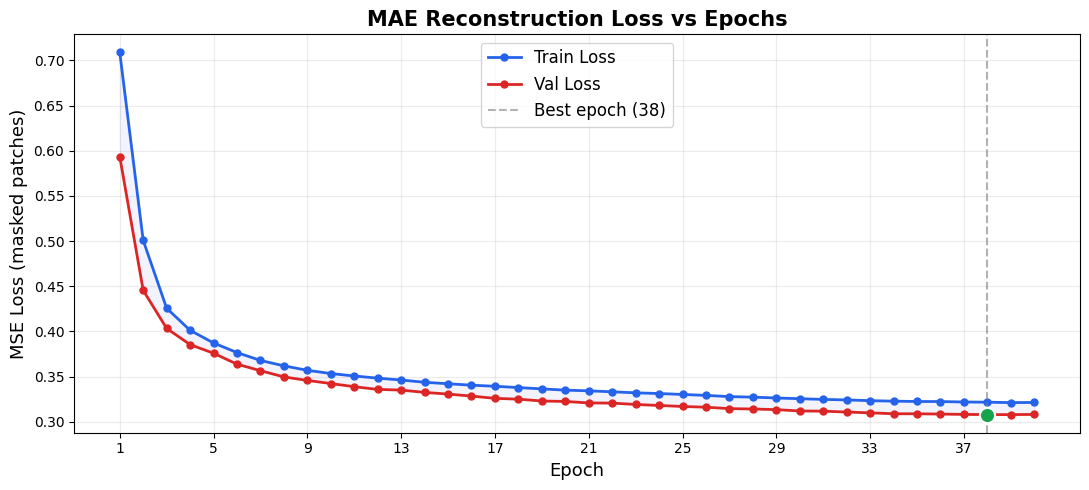

Saved: /kaggle/working/training_loss.png


In [15]:
# Loss Curve
fig,ax=plt.subplots(figsize=(11,5))
ep_x=range(1,len(train_losses)+1)
ax.plot(ep_x,train_losses,'o-',color='#2563EB',ms=5,lw=2,label='Train Loss')
ax.plot(ep_x,val_losses,  'o-',color='#DC2626',ms=5,lw=2,label='Val Loss')
best_ep=int(np.argmin(val_losses))+1
ax.axvline(best_ep,color='gray',ls='--',alpha=0.6,label=f'Best epoch ({best_ep})')
ax.scatter([best_ep],[min(val_losses)],s=120,zorder=5,
    color='#16A34A',edgecolors='white',linewidths=1.5)
ax.fill_between(ep_x,train_losses,val_losses,alpha=0.08,color='#6366F1')
ax.set_xlabel('Epoch',fontsize=13)
ax.set_ylabel('MSE Loss (masked patches)',fontsize=13)
ax.set_title('MAE Reconstruction Loss vs Epochs',fontsize=15,fontweight='bold')
ax.legend(fontsize=12); ax.grid(alpha=0.25)
step=max(1,len(train_losses)//10)
ax.set_xticks(range(1,len(train_losses)+1,step))
plt.tight_layout()
plt.savefig('/kaggle/working/training_loss.png',dpi=150,bbox_inches='tight')
plt.show(); print('Saved: /kaggle/working/training_loss.png')

## 6. Evaluation

In [16]:
best_path=cfg.BEST_CKPT if os.path.exists(cfg.BEST_CKPT) else cfg.LATEST_CKPT
ckpt=torch.load(best_path,map_location=device,weights_only=False)
raw=model.module if hasattr(model,'module') else model
raw.load_state_dict(ckpt['model_state_dict'])
raw.eval()
epoch_done = ckpt['epoch']+1
vl_done    = ckpt.get('val_loss', ckpt.get('best_val_loss','N/A'))
print(f'Loaded : {best_path}')
print(f'Epoch  : {epoch_done}  Val loss : {vl_done}')

Loaded : /kaggle/working/mae_best.pth
Epoch  : 38  Val loss : 0.3079121222320837


In [18]:
MEAN=torch.tensor([.485,.456,.406]).view(3,1,1)
STD =torch.tensor([.229,.224,.225]).view(3,1,1)
def denorm(t):
    t=t.cpu()
    m,s=(MEAN.unsqueeze(0),STD.unsqueeze(0)) if t.dim()==4 else (MEAN,STD)
    return (t*s+m).clamp(0,1)
def to_np(t): return (denorm(t).permute(1,2,0).numpy()*255).astype(np.uint8)
print('Denorm helpers  OK')

Denorm helpers  OK


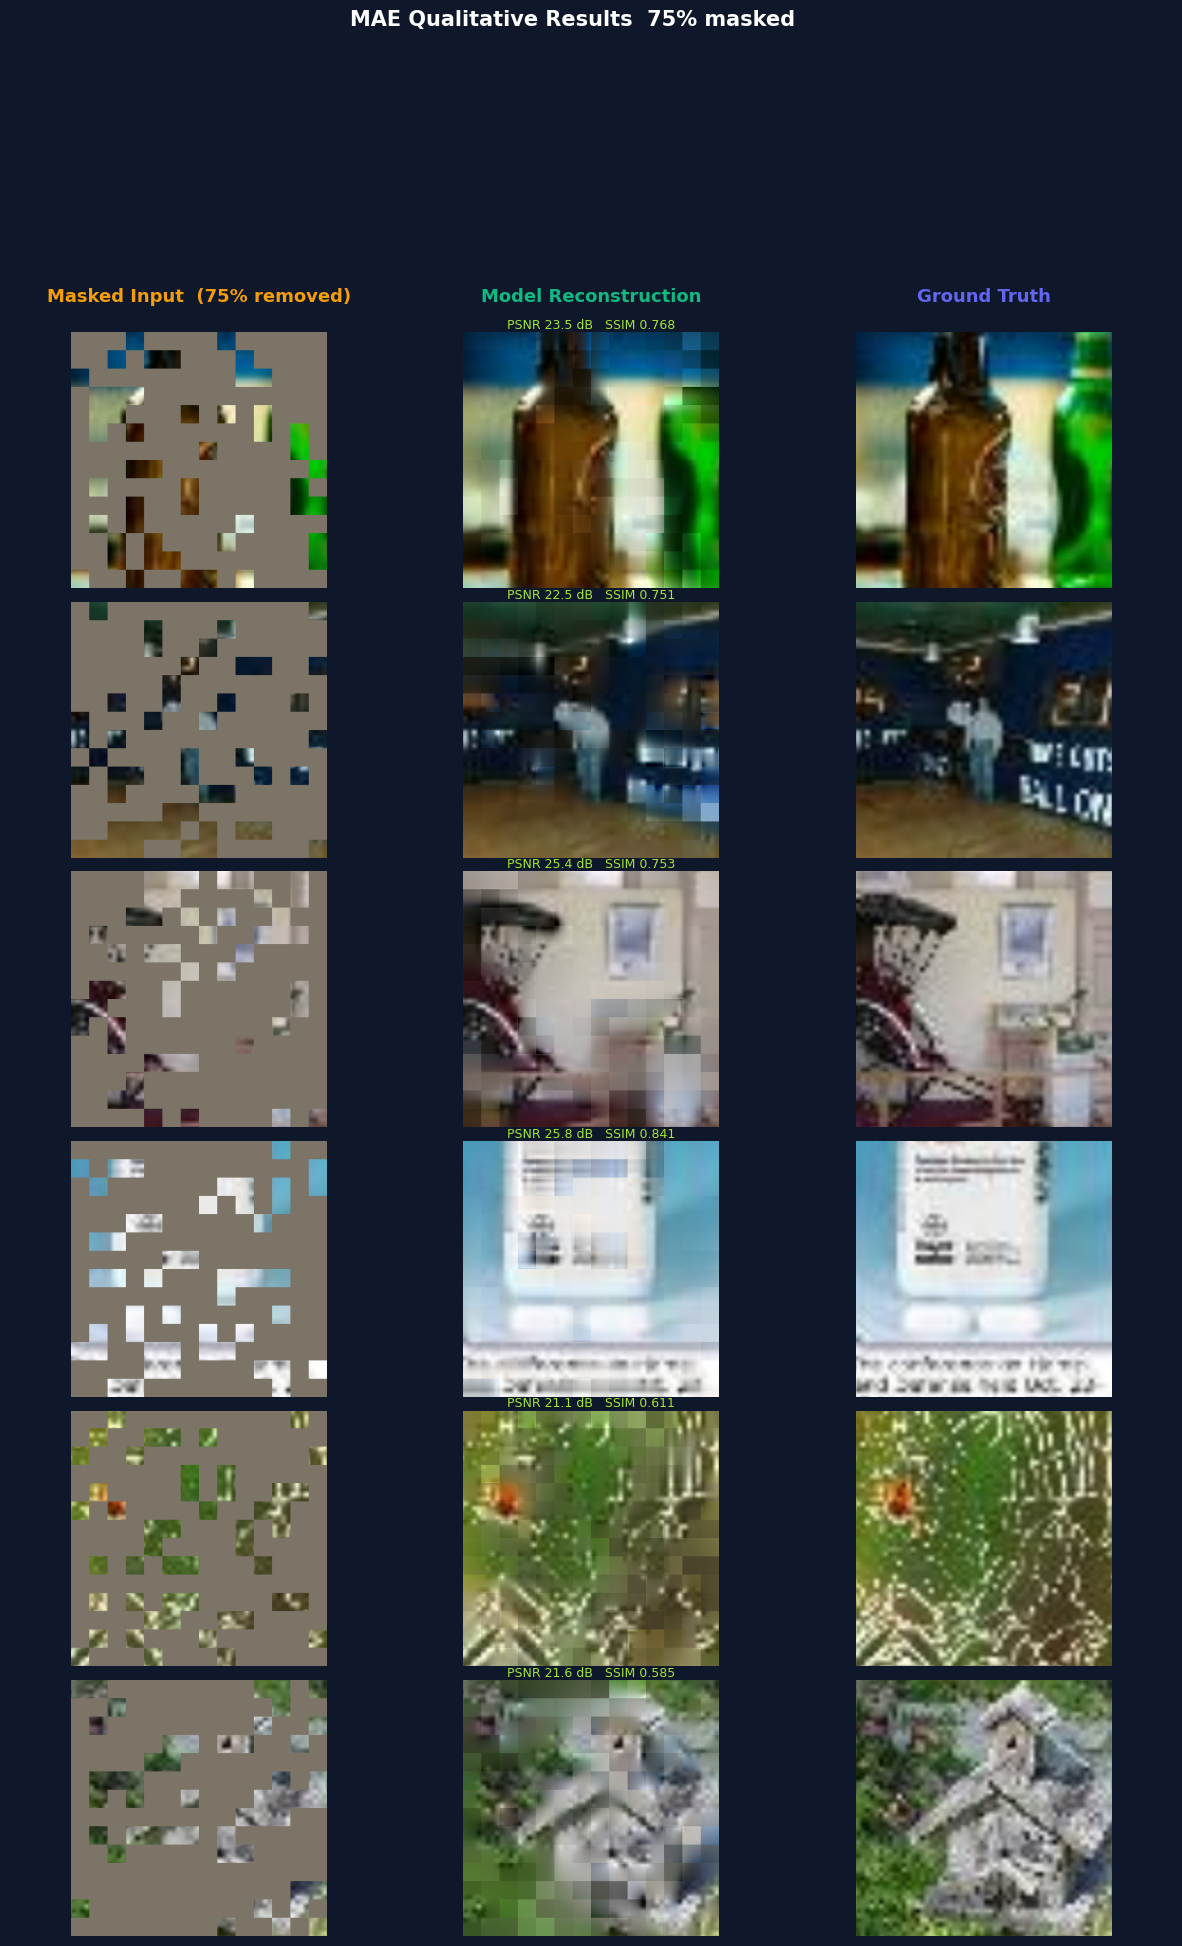

Saved: /kaggle/working/reconstructions.png  (6 samples)


In [19]:
# Part 4: Visualisation  (Masked | Reconstruction | Ground Truth)
def visualize_reconstructions(model,dataset,n=6,mask_ratio=0.75):
    model.eval()
    raw=model.module if hasattr(model,'module') else model
    idxs=random.sample(range(len(dataset)),n)
    imgs=torch.stack([dataset[i] for i in idxs]).to(device)
    with torch.no_grad():
        rc,mi,mask=raw.reconstruct(imgs,mask_ratio)
    fig=plt.figure(figsize=(15,3.6*n),facecolor='#0F172A')
    gs=gridspec.GridSpec(n+1,3,figure=fig,hspace=0.06,wspace=0.04,
        height_ratios=[0.18]+[1]*n)
    headers=['Masked Input  (75% removed)','Model Reconstruction','Ground Truth']
    hcolors=['#F59E0B','#10B981','#6366F1']
    for ci,(h,c) in enumerate(zip(headers,hcolors)):
        ax=fig.add_subplot(gs[0,ci])
        ax.text(0.5,0.5,h,ha='center',va='center',
            fontsize=13,fontweight='bold',color=c,transform=ax.transAxes)
        ax.axis('off')
    for r in range(n):
        o_np=to_np(imgs[r].cpu())
        m_np=to_np(mi[r].cpu())
        rc_np=to_np(rc[r].cpu())
        o_f=o_np.astype(np.float32)/255
        rc_f=rc_np.astype(np.float32)/255
        pv=calc_psnr(o_f,rc_f,data_range=1.0)
        sv=calc_ssim(o_f,rc_f,data_range=1.0,channel_axis=2)
        for ci,img_np in enumerate([m_np,rc_np,o_np]):
            ax=fig.add_subplot(gs[r+1,ci])
            ax.imshow(img_np); ax.axis('off')
            if ci==1:
                ax.set_title(f'PSNR {pv:.1f} dB   SSIM {sv:.3f}',
                    fontsize=9,color='#A3E635',pad=3)
    fig.suptitle(f'MAE Qualitative Results  {mask_ratio*100:.0f}% masked',
        fontsize=15,fontweight='bold',color='white',y=1.002)
    plt.savefig('/kaggle/working/reconstructions.png',dpi=150,
        bbox_inches='tight',facecolor='#0F172A')
    plt.show()
    print(f'Saved: /kaggle/working/reconstructions.png  ({n} samples)')

visualize_reconstructions(model,val_ds,n=6)

In [20]:
def evaluate(model,dataset,n=50,mask_ratio=0.75):
    model.eval()
    raw=model.module if hasattr(model,'module') else model
    ps,ss=[],[]
    for idx in random.sample(range(len(dataset)),n):
        img=dataset[idx].unsqueeze(0).to(device)
        with torch.no_grad():
            rc,_,_=raw.reconstruct(img,mask_ratio)
        o=np.clip(denorm(img[0].cpu()).permute(1,2,0).numpy(),0,1)
        r=np.clip(denorm(rc[0].cpu()).permute(1,2,0).numpy(),0,1)
        ps.append(calc_psnr(o,r,data_range=1.0))
        ss.append(calc_ssim(o,r,data_range=1.0,channel_axis=2))
    return dict(psnr_mean=np.mean(ps),psnr_std=np.std(ps),
        ssim_mean=np.mean(ss),ssim_std=np.std(ss),
        psnr_all=ps,ssim_all=ss)

metrics=evaluate(model,val_ds,n=50)
pm=metrics['psnr_mean']; ps_=metrics['psnr_std']
sm=metrics['ssim_mean']; ss_=metrics['ssim_std']
print('='*43)
print('   QUANTITATIVE EVALUATION RESULTS')
print('='*43)
print(f'  PSNR : {pm:.2f} +/- {ps_:.2f} dB')
print(f'  SSIM : {sm:.4f} +/- {ss_:.4f}')
print(f'  Eval samples : 50')
print('='*43)

   QUANTITATIVE EVALUATION RESULTS
  PSNR : 26.08 +/- 3.18 dB
  SSIM : 0.7870 +/- 0.0831
  Eval samples : 50


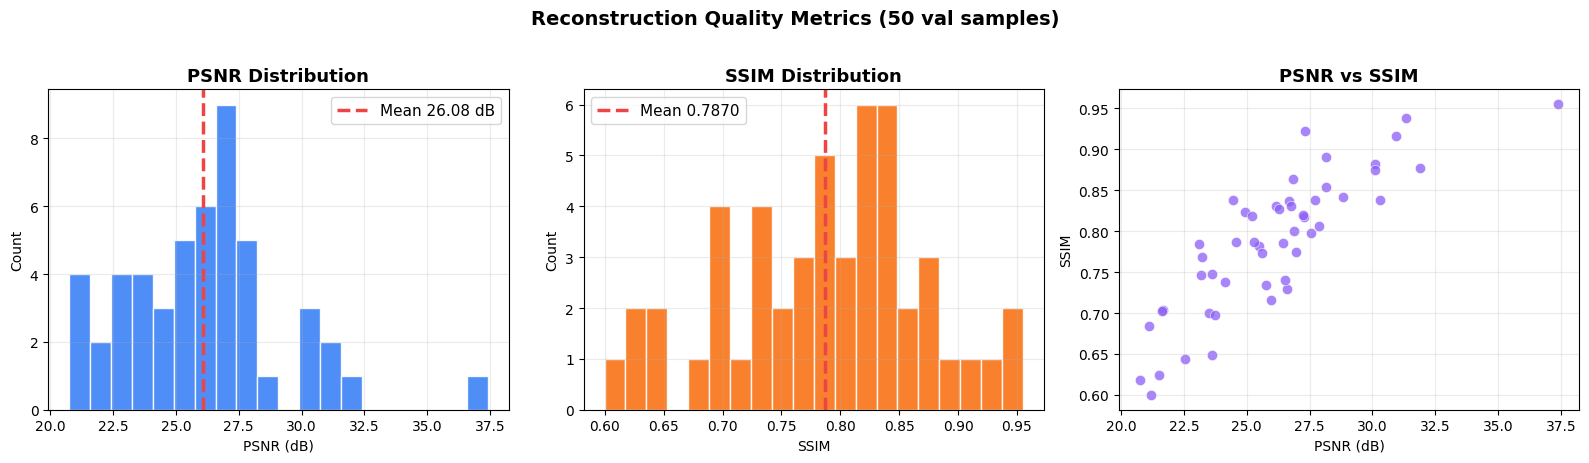

Saved: /kaggle/working/metrics_distribution.png
Rank  PSNR (dB)     SSIM      
------------------------------
1     37.41         0.9552    
2     31.88         0.8769    
3     31.32         0.9385    
4     30.92         0.9160    
5     30.30         0.8374    


In [21]:
fig,axes=plt.subplots(1,3,figsize=(16,4.5))
axes[0].hist(metrics['psnr_all'],bins=20,color='#3B82F6',edgecolor='white',alpha=0.9)
axes[0].axvline(metrics['psnr_mean'],color='#EF4444',lw=2.5,ls='--',
    label=f"Mean {metrics['psnr_mean']:.2f} dB")
axes[0].set_title('PSNR Distribution',fontsize=13,fontweight='bold')
axes[0].set_xlabel('PSNR (dB)'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=11); axes[0].grid(alpha=0.25)
axes[1].hist(metrics['ssim_all'],bins=20,color='#F97316',edgecolor='white',alpha=0.9)
axes[1].axvline(metrics['ssim_mean'],color='#EF4444',lw=2.5,ls='--',
    label=f"Mean {metrics['ssim_mean']:.4f}")
axes[1].set_title('SSIM Distribution',fontsize=13,fontweight='bold')
axes[1].set_xlabel('SSIM'); axes[1].set_ylabel('Count')
axes[1].legend(fontsize=11); axes[1].grid(alpha=0.25)
axes[2].scatter(metrics['psnr_all'],metrics['ssim_all'],
    c='#8B5CF6',s=55,alpha=0.75,edgecolors='white',linewidths=0.5)
axes[2].set_xlabel('PSNR (dB)'); axes[2].set_ylabel('SSIM')
axes[2].set_title('PSNR vs SSIM',fontsize=13,fontweight='bold')
axes[2].grid(alpha=0.25)
plt.suptitle('Reconstruction Quality Metrics (50 val samples)',
    fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/metrics_distribution.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: /kaggle/working/metrics_distribution.png')
top5=np.argsort(metrics['psnr_all'])[::-1]
print(f"{'Rank':<6}{'PSNR (dB)':<14}{'SSIM':<10}")
print('-'*30)
for rank,i in enumerate(top5[:5],1):
    print(f"{rank:<6}{metrics['psnr_all'][i]:<14.2f}{metrics['ssim_all'][i]:<10.4f}")

## 7. Gradio App

In [22]:
import gradio as gr

_pre=T.Compose([T.Resize(256),T.CenterCrop(224),T.ToTensor(),
    T.Normalize([.485,.456,.406],[.229,.224,.225])])

def _infer(pil_img,pct):
    if pil_img is None: return None,None,None,'-','-'
    x=_pre(pil_img.convert('RGB')).unsqueeze(0).to(device)
    raw=model.module if hasattr(model,'module') else model
    raw.eval()
    with torch.no_grad():
        rc,mi,_=raw.reconstruct(x,pct/100)
    o=np.clip(denorm(x[0].cpu()).permute(1,2,0).numpy(),0,1)
    m=np.clip(denorm(mi[0].cpu()).permute(1,2,0).numpy(),0,1)
    r=np.clip(denorm(rc[0].cpu()).permute(1,2,0).numpy(),0,1)
    pv=calc_psnr(o,r,data_range=1.0)
    sv=calc_ssim(o,r,data_range=1.0,channel_axis=2)
    p2i=lambda a: Image.fromarray((a*255).astype(np.uint8))
    return p2i(m),p2i(r),p2i(o),f'{pv:.2f} dB',f'{sv:.4f}'

with gr.Blocks(title='MAE Reconstruction',theme=gr.themes.Soft()) as demo:
    gr.Markdown('# Masked Autoencoder (MAE) - Live Reconstruction')
    gr.Markdown('**ViT-Base Encoder (86M) + ViT-Small Decoder (22M) | TinyImageNet**')
    gr.Markdown('Upload any image - the model reconstructs it from only 25% of patches.')
    with gr.Row():
        with gr.Column(scale=1,min_width=260):
            inp=gr.Image(type='pil',label='Upload Image')
            slider=gr.Slider(10,90,75,step=5,label='Masking Ratio (%)',
                info='75% = original MAE paper setting')
            btn=gr.Button('Reconstruct',variant='primary')
        with gr.Column(scale=3):
            with gr.Row():
                o_mask =gr.Image(label='Masked Input')
                o_recon=gr.Image(label='Reconstruction')
                o_orig =gr.Image(label='Ground Truth')
            with gr.Row():
                o_psnr=gr.Textbox(label='PSNR Score',interactive=False)
                o_ssim=gr.Textbox(label='SSIM Score',interactive=False)
    gr.Markdown('### Architecture')
    gr.Markdown('Encoder: ViT-Base B/16  12 layers  768 dim  12 heads  ~86M params')
    gr.Markdown('Decoder: ViT-Small S/16  8 layers  384 dim  6 heads  ~22M params')
    gr.Markdown('Masking: 75% masked - only 49/196 patches reach the encoder')
    gr.Markdown('Loss: MSE on masked patches only  |  Training: AdamW + Cosine LR + AMP')
    btn.click(_infer,[inp,slider],[o_mask,o_recon,o_orig,o_psnr,o_ssim])

demo.launch(share=True,debug=False,quiet=True)
print('Gradio app running - click the public URL above')

* Running on public URL: https://fba98b0f950a79330b.gradio.live


Gradio app running - click the public URL above


## 8. Summary

In [23]:
raw=model.module if hasattr(model,'module') else model
ep=sum(p.numel() for p in raw.encoder.parameters())/1e6
dp=sum(p.numel() for p in raw.decoder.parameters())/1e6
pm=metrics['psnr_mean']; sm=metrics['ssim_mean']
print('='*54)
print('       MAE ASSIGNMENT  -  FINAL SUMMARY')
print('='*54)
print(f'  Encoder : ViT-Base B/16    {ep:5.1f} M params')
print(f'  Decoder : ViT-Small S/16   {dp:5.1f} M params')
print(f'  Total   :                  {ep+dp:5.1f} M params')
print(f'  Image:224x224  Patch:16x16  Patches:196')
print(f'  Visible:49 (25%)  Masked:147 (75%)')
print('-'*54)
print(f'  Best val loss : {best_val_loss:.4f}')
print(f'  PSNR : {pm:.2f} dB')
print(f'  SSIM : {sm:.4f}')
print('-'*54)
print('  Files: mae_latest.pth  mae_best.pth')
print('         training_loss.png  reconstructions.png')
print('         metrics_distribution.png')
print('='*54)

       MAE ASSIGNMENT  -  FINAL SUMMARY
  Encoder : ViT-Base B/16     85.6 M params
  Decoder : ViT-Small S/16    14.8 M params
  Total   :                  100.4 M params
  Image:224x224  Patch:16x16  Patches:196
  Visible:49 (25%)  Masked:147 (75%)
------------------------------------------------------
  Best val loss : 0.3079
  PSNR : 26.08 dB
  SSIM : 0.7870
------------------------------------------------------
  Files: mae_latest.pth  mae_best.pth
         training_loss.png  reconstructions.png
         metrics_distribution.png
